In [1]:
!pip install pandas matplotlib

In [2]:
import sqlite3

conn = sqlite3.connect("sales_data.db")
c = conn.cursor()

c.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

rows = [
    ("2025-11-01", "Widget A", 10, 9.99),
    ("2025-11-02", "Widget B", 5, 19.50),
    ("2025-11-03", "Widget A", 3, 9.99),
    ("2025-11-04", "Widget C", 7, 5.00),
    ("2025-11-05", "Widget B", 2, 19.50),
    ("2025-11-05", "Widget C", 10, 5.00)
]

c.executemany("INSERT INTO sales (date, product, quantity, price) VALUES (?, ?, ?, ?)", rows)

conn.commit()
conn.close()

print("Database Created Successfully!")


Database Created Successfully!


In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("sales_data.db")

query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
ORDER BY revenue DESC;
"""

df = pd.read_sql_query(query, conn)
df.to_csv("sales_summary.csv", index=False)
df


,product,total_qty,revenue
0,Widget B,7,136.50
1,Widget A,13,129.87
2,Widget C,17,85.00


In [5]:
print("Sales Summary:\n")
print(df.to_string(index=False))


Sales Summary:

 product  total_qty  revenue
Widget B          7   136.50
Widget A         13   129.87
Widget C         17    85.00


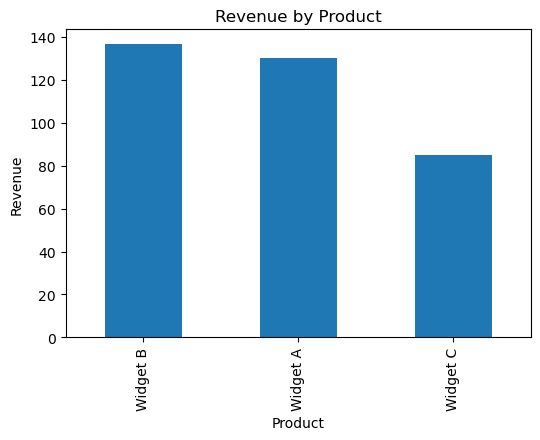

In [6]:
import matplotlib.pyplot as plt

ax = df.plot(kind='bar', x='product', y='revenue', legend=False, figsize=(6,4))
ax.set_title('Revenue by Product')
ax.set_xlabel('Product')
ax.set_ylabel('Revenue')

plt.show()


In [10]:
print("CSV file exported successfully as sales_summary.csv")


CSV file exported successfully as sales_summary.csv
